In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from numpy.ma.core import around
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,accuracy_score,r2_score
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder
from scipy import stats



In [2]:
data=pd.read_csv("ds_salaries.csv", sep=",")
print(data.head())
print(data.info())
print(data.describe())

   Unnamed: 0  work_year experience_level employment_type  \
0           0       2020               MI              FT   
1           1       2020               SE              FT   
2           2       2020               SE              FT   
3           3       2020               MI              FT   
4           4       2020               SE              FT   

                    job_title  salary salary_currency  salary_in_usd  \
0              Data Scientist   70000             EUR          79833   
1  Machine Learning Scientist  260000             USD         260000   
2           Big Data Engineer   85000             GBP         109024   
3        Product Data Analyst   20000             USD          20000   
4   Machine Learning Engineer  150000             USD         150000   

  employee_residence  remote_ratio company_location company_size  
0                 DE             0               DE            L  
1                 JP             0               JP            S  

In [3]:
data.isna().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [4]:
col_categ=[col for col in data.columns if data[col].dtype=='object']
print(col_categ)

['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


In [5]:
data_cleaning=data.copy()

In [6]:
z_score=np.abs(stats.zscore(data_cleaning["salary_in_usd"]))
threeshold=4
aoutliers=data_cleaning[z_score>threeshold]
print("nb aoutliers : \n",aoutliers["salary_in_usd"].shape)

median_salary = data_cleaning["salary_in_usd"].median()
data_cleaning.loc[z_score > threeshold, "salary_in_usd"] = median_salary


nb aoutliers : 
 (7,)


In [15]:
import plotly.io as pio
pio.renderers.default = "browser"
exp_usd=data.groupby(["job_title"])["salary_in_usd"].mean().reset_index()
exp_usd.sort_values(by="salary_in_usd", ascending=True, inplace=True)
print(exp_usd.head())
fig=px.bar(exp_usd,x="job_title",y="salary_in_usd" )
fig.show()

                        job_title  salary_in_usd
0   3D Computer Vision Researcher    5409.000000
47           Product Data Analyst   13036.000000
43                   NLP Engineer   37236.000000
10       Computer Vision Engineer   44419.333333
7               Big Data Engineer   51974.000000


In [8]:
exp_usd=data.groupby(["job_title","experience_level"])["salary_in_usd"].mean().reset_index()
exp_usd.sort_values(by="salary_in_usd", ascending=True, inplace=True)
print(exp_usd.head())
fig=px.bar(exp_usd,x="job_title",y="salary_in_usd" ,color="experience_level")
fig.show()

                         job_title experience_level  salary_in_usd
0    3D Computer Vision Researcher               MI        5409.00
100           Product Data Analyst               MI       13036.00
76                     ML Engineer               EN       18974.50
30         Data Analytics Engineer               EN       20000.00
1                     AI Scientist               EN       21987.25


In [9]:
fig=px.pie(data,names="job_title",title="nbr of job")
fig.show()

In [10]:

label=LabelEncoder()
for col in col_categ:
    data_cleaning[col]=label.fit_transform(data_cleaning[col])
print(data_cleaning.head())

   Unnamed: 0  work_year  experience_level  employment_type  job_title  \
0           0       2020                 2                2         22   
1           1       2020                 3                2         41   
2           2       2020                 3                2          7   
3           3       2020                 2                2         47   
4           4       2020                 3                2         38   

   salary  salary_currency  salary_in_usd  employee_residence  remote_ratio  \
0   70000                7          79833                  14             0   
1  260000               16         260000                  32             0   
2   85000                8         109024                  20            50   
3   20000               16          20000                  23             0   
4  150000               16         150000                  55            50   

   company_location  company_size  
0                12             0  
1       

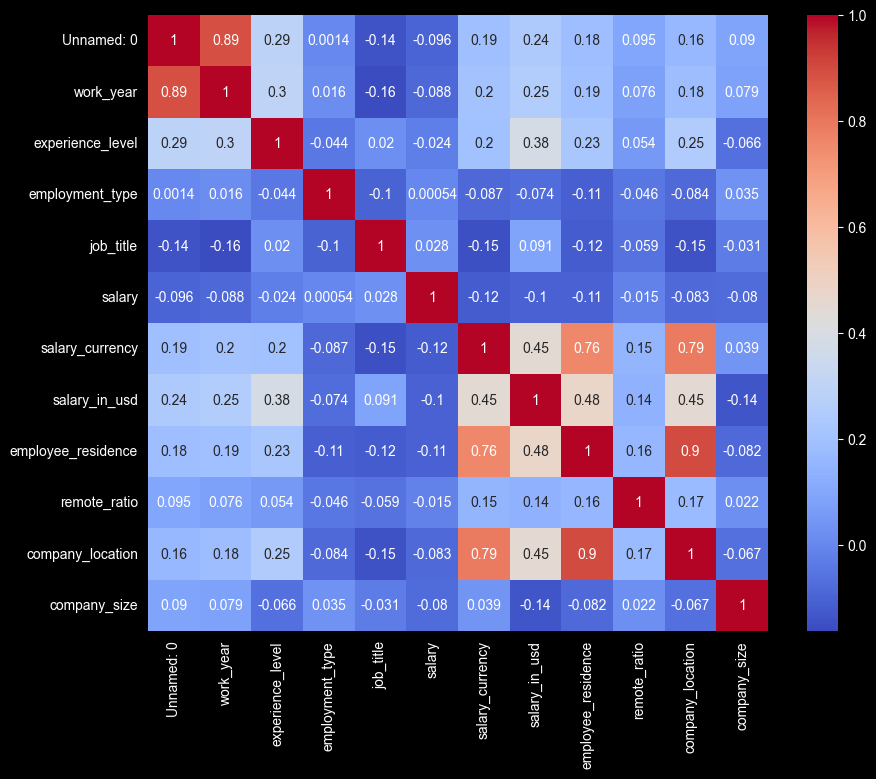

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(data_cleaning.corr(), annot=True, cmap="coolwarm")
plt.show()

In [12]:
fut=data_cleaning.drop("salary", axis=1)
tar=data["salary"]
x_train,x_test,y_train,y_test=train_test_split(fut,tar,test_size=0.2,random_state=42)
model=  LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("rondement :",round(r2_score(y_test,y_pred)*100))
print("teaux d'erreur :",round(mean_squared_error(y_test,y_pred)))
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

rondement : 1
teaux d'erreur : 8000170413063


In [13]:
model_tree=DecisionTreeRegressor()
model_tree.fit(x_train,y_train)
y_pred=model_tree.predict(x_test)
print("rondement :",round(accuracy_score(y_test,y_pred)*100))

rondement : 25


In [14]:
model=LinearRegression()
scor = cross_val_score(model,fut, tar, cv=4)
print(scor)
print("score : ",round(np.mean(scor),2))

[-0.01823563  0.00864558 -0.37778817 -2.92615583]
score :  -0.83
